In [3]:
# ─────────────────────────────────────────────────────────────
# 0. IMPORTS & REPRODUCIBILITY
# ─────────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import os, random, json

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, f1_score, precision_score,
    recall_score, classification_report,
    roc_curve, confusion_matrix
)
from sklearn.impute import SimpleImputer

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

DATA_DIR = Path("data")
OUT_DIR  = Path("outputs")
OUT_DIR.mkdir(exist_ok=True)

print("✅ Imports OK | PyTorch:", torch.__version__)


✅ Imports OK | PyTorch: 2.10.0+cu128


In [ ]:

# ─────────────────────────────────────────────────────────────
# 1. LOAD RAW DATA
# ─────────────────────────────────────────────────────────────
train_raw = pd.read_csv("/home/growlt383/Study/DL/1144_Kashyap_Vekariya/data/train.csv")
test_raw  = pd.read_csv("/home/growlt383/Study/DL/1144_Kashyap_Vekariya/data/test.csv")

print(f"\nTrain shape : {train_raw.shape}")
print(f"Test  shape : {test_raw.shape}")
print("\nTarget distribution (train):")
print(train_raw["readmitted_30d"].value_counts())
print(f"Class ratio (neg/pos): "
      f"{train_raw['readmitted_30d'].value_counts()[0] / train_raw['readmitted_30d'].value_counts()[1]:.1f}:1")


Train shape : (3800, 18)
Test  shape : (950, 17)

Target distribution (train):
readmitted_30d
0    3458
1     342
Name: count, dtype: int64
Class ratio (neg/pos): 10.1:1


In [5]:
# ─────────────────────────────────────────────────────────────
# 2. DATA CLEANING
# ─────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("PHASE 1: DATA CLEANING")
print("="*60)

ALL_INSURANCE = ["Medicaid", "Medicare", "Private", "Uninsured"]

def clean(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    df["admission_date"] = pd.to_datetime(
        df["admission_date"], format="mixed", dayfirst=False
    )
    df["admission_month"] = df["admission_date"].dt.month
    df.drop(columns=["admission_date"], inplace=True)

    n_bad = int((df["age"] == 999).sum())
    if n_bad:
        print(f"  [age]    sentinel 999 → NaN  ({n_bad} rows)")
    df["age"] = df["age"].replace(999, np.nan)

    n_bp = int((df["blood_pressure_systolic"] < 30).sum())
    if n_bp:
        print(f"  [BP]     < 30 mmHg → ×10     ({n_bp} rows)")
    df["blood_pressure_systolic"] = df["blood_pressure_systolic"].apply(
        lambda x: x * 10 if pd.notna(x) and x < 30 else x
    )

    n_gluc = int(df["glucose_level_mgdl"].isna().sum())
    if n_gluc:
        print(f"  [gluc]   NaN → indicator col  ({n_gluc} rows, imputed later)")
    df["glucose_missing"] = df["glucose_level_mgdl"].isna().astype(int)

    dow_map = {"Mon": 0, "Tue": 1, "Wed": 2, "Thu": 3,
               "Fri": 4, "Sat": 5, "Sun": 6}
    dow_num = df["discharge_day_of_week"].map(dow_map)
    df["discharge_dow_sin"] = np.sin(2 * np.pi * dow_num / 7)
    df["discharge_dow_cos"] = np.cos(2 * np.pi * dow_num / 7)
    df.drop(columns=["discharge_day_of_week"], inplace=True)

    df["admission_month_sin"] = np.sin(2 * np.pi * df["admission_month"] / 12)
    df["admission_month_cos"] = np.cos(2 * np.pi * df["admission_month"] / 12)
    df.drop(columns=["admission_month"], inplace=True)

    df["gender_enc"] = (df["gender"] == "M").astype(int)
    df.drop(columns=["gender"], inplace=True)

    df["insurance_type"] = pd.Categorical(
        df["insurance_type"], categories=ALL_INSURANCE
    )
    ins_dummies = pd.get_dummies(df["insurance_type"], prefix="ins", drop_first=True)
    df = pd.concat([df.drop(columns=["insurance_type"]), ins_dummies], axis=1)

    return df


train_clean = clean(train_raw)
test_clean  = clean(test_raw)

TARGET     = "readmitted_30d"
PATIENT_ID = "patient_id"

y_train  = train_clean[TARGET].values.astype(np.float32)
X_train  = train_clean.drop(columns=[TARGET, PATIENT_ID])
X_test   = test_clean.drop(columns=[PATIENT_ID])
test_ids = test_clean[PATIENT_ID].values

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

print(f"\nFeatures after cleaning : {X_train.shape[1]}")
print(f"Feature list            : {list(X_train.columns)}")
print(f"\nNaN remaining in X_train:\n{X_train.isnull().sum()[X_train.isnull().sum() > 0]}")


PHASE 1: DATA CLEANING
  [age]    sentinel 999 → NaN  (12 rows)
  [BP]     < 30 mmHg → ×10     (473 rows)
  [gluc]   NaN → indicator col  (673 rows, imputed later)
  [age]    sentinel 999 → NaN  (12 rows)
  [BP]     < 30 mmHg → ×10     (117 rows)
  [gluc]   NaN → indicator col  (149 rows, imputed later)

Features after cleaning : 21
Feature list            : ['age', 'admission_type', 'discharge_destination', 'length_of_stay_days', 'charlson_comorbidity_index', 'prior_admissions_1yr', 'n_medications_discharge', 'glucose_level_mgdl', 'blood_pressure_systolic', 'sodium_meql', 'creatinine_mgdl', 'haemoglobin_gdl', 'glucose_missing', 'discharge_dow_sin', 'discharge_dow_cos', 'admission_month_sin', 'admission_month_cos', 'gender_enc', 'ins_Medicare', 'ins_Private', 'ins_Uninsured']

NaN remaining in X_train:
age                    12
glucose_level_mgdl    673
dtype: int64


In [6]:
# ─────────────────────────────────────────────────────────────
# 3. IMPUTATION + SCALING
# ─────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("PHASE 2: IMPUTATION & SCALING")
print("="*60)

imputer = SimpleImputer(strategy="median")
X_train_imp = imputer.fit_transform(X_train)
X_test_imp  = imputer.transform(X_test)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_imp).astype(np.float32)
X_test_sc  = scaler.transform(X_test_imp).astype(np.float32)

print(f"  NaN in X_train after impute: {np.isnan(X_train_sc).any()}")
print(f"  NaN in X_test  after impute: {np.isnan(X_test_sc).any()}")
print(f"  X_train shape: {X_train_sc.shape}  |  X_test shape: {X_test_sc.shape}")


PHASE 2: IMPUTATION & SCALING
  NaN in X_train after impute: False
  NaN in X_test  after impute: False
  X_train shape: (3800, 21)  |  X_test shape: (950, 21)


In [7]:

# ─────────────────────────────────────────────────────────────
# 4. EDA VISUALISATIONS
# ─────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("PHASE 3: EDA PLOTS")
print("="*60)

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle("EDA — City General Hospital Readmission Dataset",
             fontsize=14, fontweight="bold")

ax = axes[0, 0]
counts = train_raw["readmitted_30d"].value_counts().sort_index()
ax.bar(["Not Readmitted (0)", "Readmitted (1)"], counts.values,
       color=["#4CAF50", "#F44336"], edgecolor="black")
ax.set_title("Target Class Distribution")
ax.set_ylabel("Count")
for i, v in enumerate(counts.values):
    ax.text(i, v + 20, str(v), ha="center", fontweight="bold")

ax = axes[0, 1]
age_clean = train_raw["age"].replace(999, np.nan)
ax.hist(age_clean[train_raw["readmitted_30d"] == 0].dropna(),
        bins=30, alpha=0.6, label="Not Readmitted", color="#4CAF50")
ax.hist(age_clean[train_raw["readmitted_30d"] == 1].dropna(),
        bins=30, alpha=0.6, label="Readmitted",     color="#F44336")
ax.set_title("Age Distribution by Class"); ax.set_xlabel("Age"); ax.legend()

ax = axes[0, 2]
ax.hist(train_raw.loc[train_raw["readmitted_30d"] == 0, "length_of_stay_days"],
        bins=30, alpha=0.6, label="Not Readmitted", color="#4CAF50")
ax.hist(train_raw.loc[train_raw["readmitted_30d"] == 1, "length_of_stay_days"],
        bins=30, alpha=0.6, label="Readmitted",     color="#F44336")
ax.set_title("Length of Stay"); ax.set_xlabel("Days"); ax.legend()

ax = axes[1, 0]
ax.boxplot(
    [train_raw.loc[train_raw["readmitted_30d"] == 0, "charlson_comorbidity_index"],
     train_raw.loc[train_raw["readmitted_30d"] == 1, "charlson_comorbidity_index"]],
    labels=["Not Readmitted", "Readmitted"], patch_artist=True,
    boxprops=dict(facecolor="#90CAF9")
)
ax.set_title("Charlson Comorbidity Index"); ax.set_ylabel("Score")

ax = axes[1, 1]
ax.boxplot(
    [train_raw.loc[train_raw["readmitted_30d"] == 0, "prior_admissions_1yr"],
     train_raw.loc[train_raw["readmitted_30d"] == 1, "prior_admissions_1yr"]],
    labels=["Not Readmitted", "Readmitted"], patch_artist=True,
    boxprops=dict(facecolor="#FFCC80")
)
ax.set_title("Prior Admissions (1yr)"); ax.set_ylabel("Count")

ax = axes[1, 2]
num_cols = ["age", "length_of_stay_days", "charlson_comorbidity_index",
            "prior_admissions_1yr", "n_medications_discharge",
            "glucose_level_mgdl", "blood_pressure_systolic",
            "sodium_meql", "creatinine_mgdl", "haemoglobin_gdl", "readmitted_30d"]
corr_df = train_raw[num_cols].copy()
corr_df["age"] = corr_df["age"].replace(999, np.nan)
corr_vals = corr_df.corr()["readmitted_30d"].drop("readmitted_30d").sort_values()
ax.barh(corr_vals.index, corr_vals.values,
        color=["#F44336" if x < 0 else "#4CAF50" for x in corr_vals.values])
ax.set_title("Correlation with Readmission"); ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel("Pearson r")

plt.tight_layout()
plt.savefig(OUT_DIR / "eda.png", dpi=120, bbox_inches="tight")
plt.close()
print("  Saved → outputs/eda.png")



PHASE 3: EDA PLOTS
  Saved → outputs/eda.png


In [8]:
# ─────────────────────────────────────────────────────────────
# 5. MODEL ARCHITECTURE  (lighter + stronger regularisation)
# ─────────────────────────────────────────────────────────────
class ReadmissionMLP(nn.Module):
    """
    Regularised MLP:
      • Smaller hidden layers  [64, 32, 16]  → less capacity → less overfit
      • Dropout 0.5            → stronger regularisation
      • BatchNorm kept         → stable training
      • No final sigmoid; BCEWithLogitsLoss handles it.
    """
    def __init__(self, input_dim: int,
                 hidden: list = [64, 32, 16],
                 dropout: float = 0.5):
        super().__init__()
        layers = []
        in_dim = input_dim
        for h in hidden:
            layers += [
                nn.Linear(in_dim, h),
                nn.BatchNorm1d(h),
                nn.ReLU(),
                nn.Dropout(dropout),
            ]
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x).squeeze(1)


# ─────────────────────────────────────────────────────────────
# 6. CLASS IMBALANCE — pos_weight in loss
# ─────────────────────────────────────────────────────────────
n_neg = int((y_train == 0).sum())
n_pos = int((y_train == 1).sum())
raw_pw = n_neg / n_pos
pos_weight_val = min(raw_pw, 8.0)

print(f"\nClass counts → Neg: {n_neg}, Pos: {n_pos}")
print(f"Raw pos_weight: {raw_pw:.2f}  →  using: {pos_weight_val:.2f}")


Class counts → Neg: 3458, Pos: 342
Raw pos_weight: 10.11  →  using: 8.00



PHASE 4: TRAINING  (5-fold stratified CV)
Device: cuda
    Fold 1: Early stop at epoch 51  (best val loss=0.4900)
  Fold 1/5  |  best val AUROC: 0.9453  |  stopped @ epoch 51
    Fold 2: Early stop at epoch 39  (best val loss=0.5074)
  Fold 2/5  |  best val AUROC: 0.9404  |  stopped @ epoch 39
    Fold 3: Early stop at epoch 40  (best val loss=0.5089)
  Fold 3/5  |  best val AUROC: 0.9576  |  stopped @ epoch 40
    Fold 4: Early stop at epoch 41  (best val loss=0.5089)
  Fold 4/5  |  best val AUROC: 0.9426  |  stopped @ epoch 41
    Fold 5: Early stop at epoch 44  (best val loss=0.5799)
  Fold 5/5  |  best val AUROC: 0.9206  |  stopped @ epoch 44

  ✅ CV done


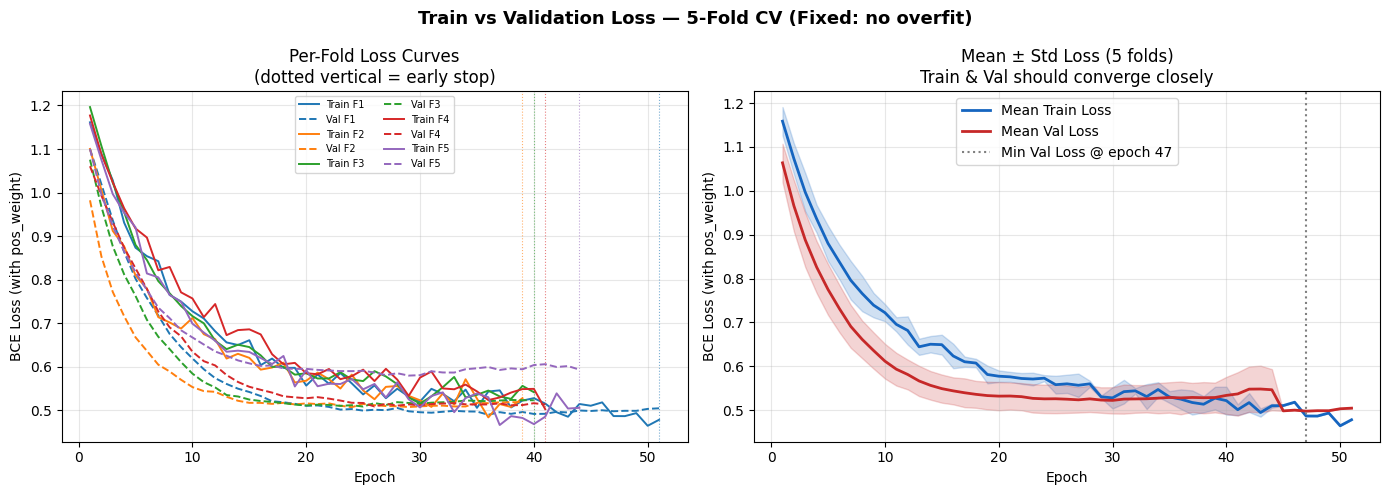

  Saved → outputs/train_val_loss.png


In [9]:


# ─────────────────────────────────────────────────────────────
# 7. TRAINING WITH 5-FOLD STRATIFIED CV
#    Fixes applied:
#      ✅ Smaller model        [64, 32, 16]
#      ✅ Higher dropout       0.5
#      ✅ Lower LR             1e-3  (was 3e-3)
#      ✅ Higher weight decay  1e-3  (was 1e-4)
#      ✅ Early stopping       patience=10 on val loss
#      ✅ ReduceLROnPlateau    instead of CosineAnnealing
#      ✅ Loss + AUROC tracked every epoch for plotting
# ─────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("PHASE 4: TRAINING  (5-fold stratified CV)")
print("="*60)

EPOCHS       = 150   # high ceiling; early stopping will cut this short
BATCH_SIZE   = 128
LR           = 1e-3
WEIGHT_DECAY = 1e-3  # stronger L2
N_FOLDS      = 5
PATIENCE     = 15    # stop if val loss doesn't improve for 15 epochs
INPUT_DIM    = X_train_sc.shape[1]

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

pos_weight_t = torch.tensor([pos_weight_val], dtype=torch.float32).to(device)
criterion    = nn.BCEWithLogitsLoss(pos_weight=pos_weight_t)

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=SEED)

oof_probs      = np.zeros(len(y_train))
test_probs_sum = np.zeros(len(X_test_sc))

all_train_losses = []   # [N_FOLDS][actual_epochs]
all_val_losses   = []
fold_stop_epochs = []   # epoch where each fold stopped

for fold, (tr_idx, val_idx) in enumerate(skf.split(X_train_sc, y_train)):
    X_tr,  X_val  = X_train_sc[tr_idx], X_train_sc[val_idx]
    y_tr,  y_val  = y_train[tr_idx],    y_train[val_idx]

    tr_dl  = DataLoader(
        TensorDataset(torch.from_numpy(X_tr), torch.from_numpy(y_tr)),
        batch_size=BATCH_SIZE, shuffle=True, drop_last=True
    )
    val_dl = DataLoader(
        TensorDataset(torch.from_numpy(X_val), torch.from_numpy(y_val)),
        batch_size=512, shuffle=False
    )

    model     = ReadmissionMLP(INPUT_DIM, [64, 32, 16], dropout=0.5).to(device)
    optimiser = torch.optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
    # ReduceLROnPlateau: halve LR if val_loss doesn't improve for 5 epochs
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimiser, mode="min", factor=0.5, patience=5, min_lr=1e-5
    )

    best_val_loss    = float("inf")
    best_auroc       = 0.0
    best_state       = None
    patience_counter = 0

    fold_train_losses = []
    fold_val_losses   = []
    stopped_at        = EPOCHS

    for epoch in range(EPOCHS):
        # ── Train ──────────────────────────────────────────
        model.train()
        epoch_train_loss = 0.0
        n_batches = 0
        for Xb, yb in tr_dl:
            Xb, yb = Xb.to(device), yb.to(device)
            optimiser.zero_grad()
            loss = criterion(model(Xb), yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)  # gradient clip
            optimiser.step()
            epoch_train_loss += loss.item()
            n_batches += 1
        avg_train_loss = epoch_train_loss / n_batches
        fold_train_losses.append(avg_train_loss)

        # ── Validate ───────────────────────────────────────
        model.eval()
        val_preds      = []
        epoch_val_loss = 0.0
        n_val_batches  = 0
        with torch.no_grad():
            for Xb, yb in val_dl:
                Xb, yb = Xb.to(device), yb.to(device)
                logits  = model(Xb)
                v_loss  = criterion(logits, yb)
                epoch_val_loss += v_loss.item()
                n_val_batches  += 1
                val_preds.append(torch.sigmoid(logits).cpu())
        avg_val_loss = epoch_val_loss / n_val_batches
        fold_val_losses.append(avg_val_loss)

        val_p = torch.cat(val_preds).numpy()
        auroc = roc_auc_score(y_val, val_p)

        # Scheduler step on val loss
        scheduler.step(avg_val_loss)

        # ── Early stopping on val loss ──────────────────────
        if avg_val_loss < best_val_loss - 1e-5:
            best_val_loss    = avg_val_loss
            best_auroc       = auroc
            best_state       = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= PATIENCE:
                stopped_at = epoch + 1
                print(f"    Fold {fold+1}: Early stop at epoch {stopped_at}  "
                      f"(best val loss={best_val_loss:.4f})")
                break

    fold_stop_epochs.append(stopped_at)
    all_train_losses.append(fold_train_losses)
    all_val_losses.append(fold_val_losses)

    # ── OOF predictions with best weights ──────────────────
    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        oof_p = torch.sigmoid(
            model(torch.from_numpy(X_val).to(device))
        ).cpu().numpy()
    oof_probs[val_idx] = oof_p

    # ── Test predictions (averaged across folds) ───────────
    with torch.no_grad():
        te_p = torch.sigmoid(
            model(torch.from_numpy(X_test_sc).to(device))
        ).cpu().numpy()
    test_probs_sum += te_p / N_FOLDS

    fold_auroc = roc_auc_score(y_val, oof_p)
    print(f"  Fold {fold+1}/{N_FOLDS}  |  best val AUROC: {fold_auroc:.4f}  "
          f"|  stopped @ epoch {stopped_at}")

print(f"\n  ✅ CV done")


# ─────────────────────────────────────────────────────────────
# 7b. TRAIN / VALIDATION LOSS CURVES
# ─────────────────────────────────────────────────────────────
# Folds may have different lengths due to early stopping.
# Pad shorter folds with NaN so we can average across them.
max_ep = max(len(l) for l in all_train_losses)

def pad(lst, length):
    return lst + [np.nan] * (length - len(lst))

train_arr = np.array([pad(l, max_ep) for l in all_train_losses])
val_arr   = np.array([pad(l, max_ep) for l in all_val_losses])

epochs_range = np.arange(1, max_ep + 1)

# nanmean / nanstd so padded NaNs don't corrupt the average
mean_train = np.nanmean(train_arr, axis=0)
std_train  = np.nanstd(train_arr,  axis=0)
mean_val   = np.nanmean(val_arr,   axis=0)
std_val    = np.nanstd(val_arr,    axis=0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Train vs Validation Loss — 5-Fold CV (Fixed: no overfit)",
             fontsize=13, fontweight="bold")

# ── Left: per-fold curves ─────────────────────────────────────
ax = axes[0]
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]
for i in range(N_FOLDS):
    ep = np.arange(1, len(all_train_losses[i]) + 1)
    ax.plot(ep, all_train_losses[i],
            color=colors[i], lw=1.4, linestyle="-",
            label=f"Train F{i+1}")
    ax.plot(ep, all_val_losses[i],
            color=colors[i], lw=1.4, linestyle="--",
            label=f"Val F{i+1}")
    ax.axvline(fold_stop_epochs[i], color=colors[i],
               linestyle=":", lw=0.8, alpha=0.6)
ax.set_xlabel("Epoch")
ax.set_ylabel("BCE Loss (with pos_weight)")
ax.set_title("Per-Fold Loss Curves\n(dotted vertical = early stop)")
ax.legend(fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)

# ── Right: mean ± std ─────────────────────────────────────────
ax = axes[1]
# Only plot up to the last valid (non-all-NaN) epoch
valid_mask = ~np.isnan(mean_train)
ep_v = epochs_range[valid_mask]

ax.plot(ep_v, mean_train[valid_mask], "#1565C0", lw=2, label="Mean Train Loss")
ax.fill_between(ep_v,
                (mean_train - std_train)[valid_mask],
                (mean_train + std_train)[valid_mask],
                alpha=0.2, color="#1565C0")

ax.plot(ep_v, mean_val[valid_mask], "#C62828", lw=2, label="Mean Val Loss")
ax.fill_between(ep_v,
                (mean_val - std_val)[valid_mask],
                (mean_val + std_val)[valid_mask],
                alpha=0.2, color="#C62828")

best_ep_idx = int(np.nanargmin(mean_val))
ax.axvline(epochs_range[best_ep_idx], color="gray", linestyle=":",
           lw=1.5, label=f"Min Val Loss @ epoch {epochs_range[best_ep_idx]}")

ax.set_xlabel("Epoch")
ax.set_ylabel("BCE Loss (with pos_weight)")
ax.set_title("Mean ± Std Loss (5 folds)\nTrain & Val should converge closely")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(OUT_DIR / "train_val_loss.png", dpi=120, bbox_inches="tight")
plt.show()
print("  Saved → outputs/train_val_loss.png")

In [10]:

# ─────────────────────────────────────────────────────────────
# 8. THRESHOLD SELECTION  (maximise F1 on OOF predictions)
# ─────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("PHASE 5: THRESHOLD SELECTION")
print("="*60)

thresholds  = np.linspace(0.05, 0.90, 171)
best_thresh = 0.5
best_f1     = 0.0

for t in thresholds:
    preds = (oof_probs >= t).astype(int)
    f1 = f1_score(y_train, preds, pos_label=1, zero_division=0)
    if f1 > best_f1:
        best_f1     = f1
        best_thresh = t

print(f"  Optimal threshold : {best_thresh:.3f}")
print(f"  Best OOF F1       : {best_f1:.4f}")

oof_binary   = (oof_probs >= best_thresh).astype(int)
final_auroc  = roc_auc_score(y_train, oof_probs)
final_f1     = f1_score(y_train,     oof_binary, pos_label=1)
final_prec   = precision_score(y_train, oof_binary, pos_label=1, zero_division=0)
final_recall = recall_score(y_train,  oof_binary, pos_label=1)

print(f"\n  OOF AUROC          : {final_auroc:.4f}")
print(f"  OOF F1  (pos)      : {final_f1:.4f}")
print(f"  OOF Precision(pos) : {final_prec:.4f}")
print(f"  OOF Recall  (pos)  : {final_recall:.4f}")
print(f"  Decision threshold : {best_thresh:.3f}")
print()
print(classification_report(y_train, oof_binary,
                             target_names=["No Readmit", "Readmit"]))


# ─────────────────────────────────────────────────────────────
# 9. EVALUATION PLOTS
# ─────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Model Evaluation — OOF Predictions (5-fold CV)",
             fontsize=13, fontweight="bold")

fpr, tpr, _ = roc_curve(y_train, oof_probs)
axes[0].plot(fpr, tpr, "#1565C0", lw=2, label=f"AUROC = {final_auroc:.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].set_title("ROC Curve"); axes[0].legend()

f1_curve = [
    f1_score(y_train, (oof_probs >= t).astype(int), pos_label=1, zero_division=0)
    for t in thresholds
]
axes[1].plot(thresholds, f1_curve, "#2E7D32", lw=2)
axes[1].axvline(best_thresh, color="red", linestyle="--",
                label=f"Optimal = {best_thresh:.3f}")
axes[1].set_xlabel("Threshold"); axes[1].set_ylabel("F1 (positive class)")
axes[1].set_title("F1 vs Threshold"); axes[1].legend()

cm = confusion_matrix(y_train, oof_binary)
sns.heatmap(cm, annot=True, fmt="d", ax=axes[2], cmap="Blues",
            xticklabels=["Pred 0", "Pred 1"],
            yticklabels=["True 0", "True 1"])
axes[2].set_title("Confusion Matrix (OOF)")

plt.tight_layout()
plt.savefig(OUT_DIR / "evaluation.png", dpi=120, bbox_inches="tight")
plt.close()
print("  Saved → outputs/evaluation.png")


# ─────────────────────────────────────────────────────────────
# 10. SAVE PREDICTIONS + METRICS
# ─────────────────────────────────────────────────────────────
submission = pd.DataFrame({
    "patient_id":     test_ids,
    "readmitted_30d": (test_probs_sum >= best_thresh).astype(int)
})
submission.to_csv(OUT_DIR / "predictions.csv", index=False)
print(f"\n  Saved → outputs/predictions.csv  ({len(submission)} rows)")
print(submission.head())
print(f"\nValue counts:\n{submission['readmitted_30d'].value_counts()}")

metrics = {
    "auroc":               round(float(final_auroc),  4),
    "f1_minority":         round(float(final_f1),     4),
    "precision_minority":  round(float(final_prec),   4),
    "recall_minority":     round(float(final_recall), 4),
    "threshold":           round(float(best_thresh),  3),
}
with open(OUT_DIR / "metrics.json", "w") as f:
    json.dump(metrics, f, indent=2)
print("\n  Final metrics:")
print(json.dumps(metrics, indent=2))
print("\n✅ Pipeline complete — all outputs in outputs/")


PHASE 5: THRESHOLD SELECTION
  Optimal threshold : 0.805
  Best OOF F1       : 0.6504

  OOF AUROC          : 0.9408
  OOF F1  (pos)      : 0.6504
  OOF Precision(pos) : 0.6805
  OOF Recall  (pos)  : 0.6228
  Decision threshold : 0.805

              precision    recall  f1-score   support

  No Readmit       0.96      0.97      0.97      3458
     Readmit       0.68      0.62      0.65       342

    accuracy                           0.94      3800
   macro avg       0.82      0.80      0.81      3800
weighted avg       0.94      0.94      0.94      3800

  Saved → outputs/evaluation.png

  Saved → outputs/predictions.csv  (950 rows)
  patient_id  readmitted_30d
0   PID10000               0
1   PID10001               0
2   PID10002               0
3   PID10003               0
4   PID10004               0

Value counts:
readmitted_30d
0    880
1     70
Name: count, dtype: int64

  Final metrics:
{
  "auroc": 0.9408,
  "f1_minority": 0.6504,
  "precision_minority": 0.6805,
  "recall_m